# Aether Biophysical Neuron Suite

Demonstrates the real, tested engines in `aether_neuro_core`: the vectorized Hodgkin-Huxley engine and the Hines-style multi-compartment solver. Every cell here runs against actual code in this repo (no placeholder output).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from aether_neuro_core.engines.hodgkin_huxley_vec import HighThroughputHHEngine, detect_spikes
from aether_neuro_core.engines.multi_compartment import Compartment, MultiCompartmentNeuronEngine
from aether_neuro_core.agents.molecular_agent import MolecularNeuroAgent

## 1. Single-neuron spike train under a current step

spike count: 4


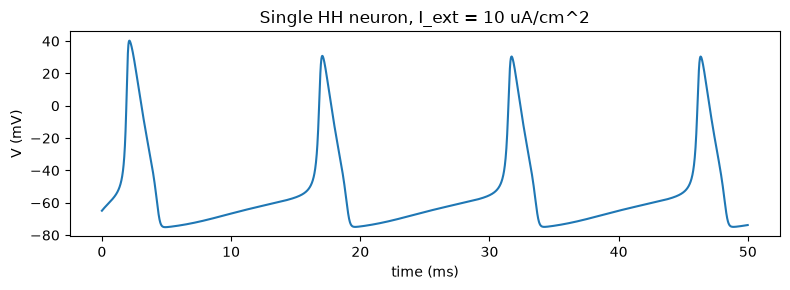

In [2]:
dt = 0.01  # ms
n_steps = 5000  # 50 ms
engine = HighThroughputHHEngine(batch_size=1, dt=dt, seed=0)
trace = engine.run(n_steps=n_steps, i_ext=10.0, method="rk4")

t = np.arange(n_steps) * dt
spikes = detect_spikes(trace, threshold=0.0)
print(f"spike count: {int(spikes.sum())}")

plt.figure(figsize=(8, 3))
plt.plot(t, trace[:, 0])
plt.xlabel("time (ms)")
plt.ylabel("V (mV)")
plt.title("Single HH neuron, I_ext = 10 uA/cm^2")
plt.tight_layout()

## 2. Batched parameter sweep across ion-channel variants

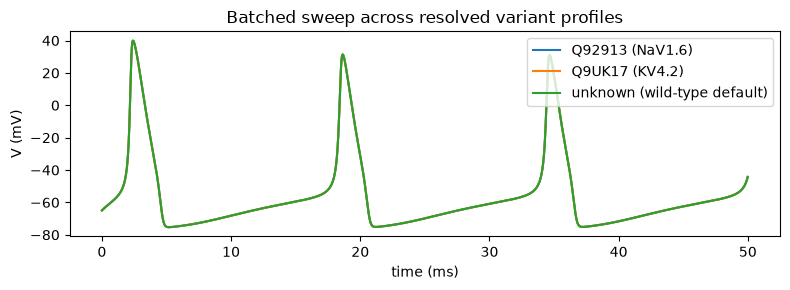

In [3]:
agent = MolecularNeuroAgent()
sweep_engine = agent.ion_channel_modeler(["Q92913", "Q9UK17", "UNKNOWN_ACCESSION"], dt=dt, seed=0)
sweep_trace = sweep_engine.run(n_steps=n_steps, i_ext=8.0, method="rk4")

plt.figure(figsize=(8, 3))
for i, label in enumerate(["Q92913 (NaV1.6)", "Q9UK17 (KV4.2)", "unknown (wild-type default)"]):
    plt.plot(t, sweep_trace[:, i], label=label)
plt.xlabel("time (ms)")
plt.ylabel("V (mV)")
plt.legend()
plt.title("Batched sweep across resolved variant profiles")
plt.tight_layout()

## 3. Multi-compartment neuron: current injected into the soma, coupling into the dendrite

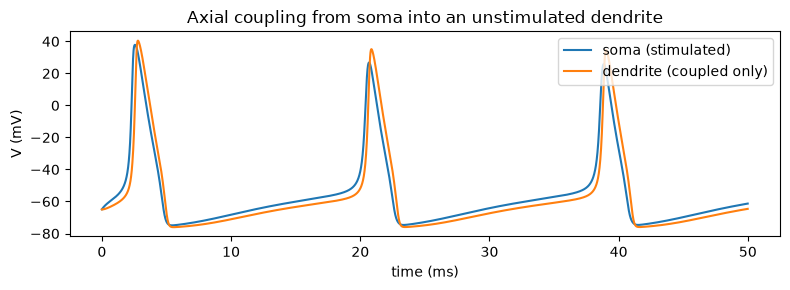

In [4]:
soma = Compartment(name="soma", parent=None, diam_um=20.0, length_um=20.0)
dend = Compartment(name="dend", parent="soma", diam_um=2.0, length_um=200.0)
neuron = MultiCompartmentNeuronEngine([soma, dend], dt=dt, seed=0)

mc_trace = neuron.run(n_steps=n_steps, i_ext=[12.0, 0.0])

plt.figure(figsize=(8, 3))
plt.plot(t, mc_trace[:, neuron.index_of("soma")], label="soma (stimulated)")
plt.plot(t, mc_trace[:, neuron.index_of("dend")], label="dendrite (coupled only)")
plt.xlabel("time (ms)")
plt.ylabel("V (mV)")
plt.legend()
plt.title("Axial coupling from soma into an unstimulated dendrite")
plt.tight_layout()

## 4. Stochastic (Euler-Maruyama) inter-spike-interval variability

In [5]:
noisy_engine = HighThroughputHHEngine(batch_size=3, dt=dt, seed=42)
noisy_trace = noisy_engine.run(n_steps=n_steps, i_ext=6.0, sigma=15.0, method="euler_maruyama")

spike_mask = detect_spikes(noisy_trace, threshold=0.0)
for i in range(3):
    spike_times = t[spike_mask[:, i]]
    isis = np.diff(spike_times)
    print(f"neuron {i}: {len(spike_times)} spikes, ISI mean/std = {isis.mean():.2f} / {isis.std():.2f} ms" if len(isis) else f"neuron {i}: fewer than 2 spikes")

neuron 0: 7 spikes, ISI mean/std = 6.89 / 6.41 ms
neuron 1: 7 spikes, ISI mean/std = 6.27 / 5.71 ms
neuron 2: 9 spikes, ISI mean/std = 4.61 / 5.78 ms
